# Custom SpectrumEmulator with linear limb darkening

This notebook builds a minimal `SpectrumEmulator` that returns a stored
spectrum (loaded from `data/test_spectrum.pkl`) and applies the linear
limb-darkening law:

$$\frac{I(\mu)}{I(1)} = 1 - a\,(1-\mu)$$

We pass that emulator through `simulate_observed_flux` on a single
icosphere and check that the output matches the input spectrum (up to
the disk-integration prefactor predicted analytically).

For a uniform sphere, integrating $I(\mu)\,\mu\,\mathrm{d}A$ over the
visible hemisphere gives $\pi R^2 (1 - a/3)\,I(1)$, so SPICE's observed
flux should be

$$F_{\mathrm{obs}}(\lambda) \approx \pi\,(1 - a/3)\,I(1, \lambda)\,
\left(\frac{R}{d}\right)^2.$$

In [49]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import pickle
from typing import Any, Dict, List, Optional

import jax
# Match SPICE's test configuration: the wavelength <-> log10(wavelength)
# round trip and jnp.interp need 64-bit precision, otherwise a few sharp
# lines pick up ~half-a-pixel sampling errors at the red end of the grid.
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Use the in-repo source tree if SPICE isn't pip-installed (run from tutorial/).
import sys
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from spice.models import IcosphereModel
from spice.spectrum import simulate_observed_flux

%matplotlib inline

## 1. Load the reference spectrum

The pickle stores `wavelength`, `flux`, and `continuum` arrays
(200 001 points across 4000–8000 Å). We treat the stored values as the
specific intensity at the disk centre, $I(\mu=1, \lambda)$, in units of
erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$ sr$^{-1}$.

Wavelength range: 4000.0 - 8000.0 A (200001 points)
Flux range:      6.034e+05 - 1.136e+07
Continuum range: 5.233e+06 - 1.136e+07


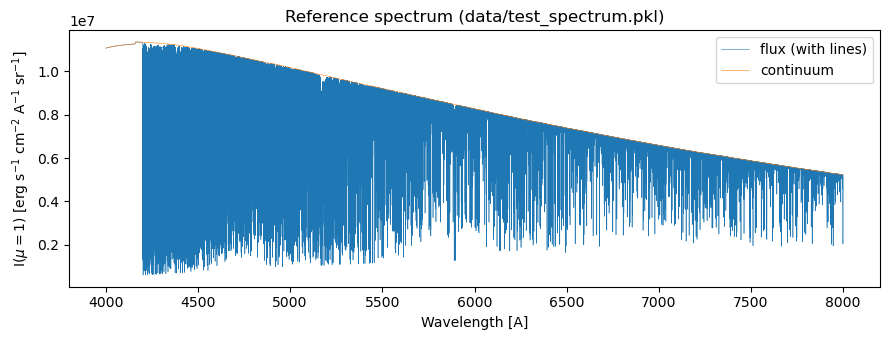

In [50]:
with open('../data/test_spectrum.pkl', 'rb') as f:
    spectrum_data = pickle.load(f)

ref_wavelengths = np.asarray(spectrum_data['wavelength'], dtype=np.float64)
ref_flux = np.asarray(spectrum_data['flux'], dtype=np.float64)
ref_continuum = np.asarray(spectrum_data['continuum'], dtype=np.float64)

print(f'Wavelength range: {ref_wavelengths.min():.1f} - {ref_wavelengths.max():.1f} A '
      f'({ref_wavelengths.size} points)')
print(f'Flux range:      {ref_flux.min():.3e} - {ref_flux.max():.3e}')
print(f'Continuum range: {ref_continuum.min():.3e} - {ref_continuum.max():.3e}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(ref_wavelengths, ref_flux, lw=0.4, label='flux (with lines)', color='C0')
ax.plot(ref_wavelengths, ref_continuum, lw=0.4, label='continuum', color='C1')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('I($\\mu=1$) [erg s$^{-1}$ cm$^{-2}$ A$^{-1}$ sr$^{-1}$]')
ax.legend()
ax.set_title('Reference spectrum (data/test_spectrum.pkl)')
plt.tight_layout()
plt.show()

## 2. Define the custom emulator

The class follows the same interface as `spice.spectrum.Blackbody`: it
exposes `parameter_names`, `to_parameters`, `flux`, and `intensity`.
The `intensity` method JIT-compiles cleanly because the stored
wavelength/flux/continuum tables are captured as `jnp.ndarray` closures
and the per-element work is just `jnp.interp` plus a linear LD factor.

`intensity` must return a `(n_wavelengths, 2)` array — the two columns
are the line spectrum and the continuum, mirroring SPICE's other
emulators.

In [51]:
class StoredSpectrumEmulator:
    """SpectrumEmulator that returns a tabulated spectrum with linear LD."""

    def __init__(self,
                 wavelengths: np.ndarray,
                 flux: np.ndarray,
                 continuum: np.ndarray,
                 ld_a: float = 0.6):
        self._wavelengths = jnp.asarray(wavelengths)
        self._flux = jnp.asarray(flux)
        self._continuum = jnp.asarray(continuum)
        self.ld_a = float(ld_a)

    @property
    def parameter_names(self) -> List[str]:
        # No tunable stellar parameters — a single dummy slot keeps the
        # MeshModel.parameters array two-dimensional as SPICE expects.
        return ['dummy']

    @property
    def stellar_parameter_names(self) -> List[str]:
        return self.parameter_names

    @property
    def solar_parameters(self) -> jnp.ndarray:
        return jnp.array([0.0])

    def to_parameters(self, parameter_values: Optional[Dict[str, Any]] = None) -> jnp.ndarray:
        return self.solar_parameters

    def intensity(self,
                  log_wavelengths: jnp.ndarray,
                  mu: float,
                  parameters: jnp.ndarray) -> jnp.ndarray:
        wavelengths = jnp.power(10.0, log_wavelengths)
        flux_interp = jnp.interp(wavelengths, self._wavelengths, self._flux)
        continuum_interp = jnp.interp(wavelengths, self._wavelengths, self._continuum)
        # Linear limb-darkening factor: I(mu) / I(1) = 1 - a (1 - mu)
        mu_safe = jnp.clip(mu, 0.0, 1.0)
        ld_factor = 1.0 - self.ld_a * (1.0 - mu_safe)
        return jnp.stack([flux_interp * ld_factor,
                          continuum_interp * ld_factor], axis=-1)

    def flux(self,
             log_wavelengths: jnp.ndarray,
             parameters: jnp.ndarray) -> jnp.ndarray:
        return self.intensity(log_wavelengths, 1.0, parameters)


LD_A = 0.6
emulator = StoredSpectrumEmulator(ref_wavelengths, ref_flux, ref_continuum, ld_a=LD_A)

Quick sanity check: at $\mu = 1$ the emulator should reproduce the input,
and at smaller $\mu$ the spectrum should be scaled by $1 - a(1-\mu)$.

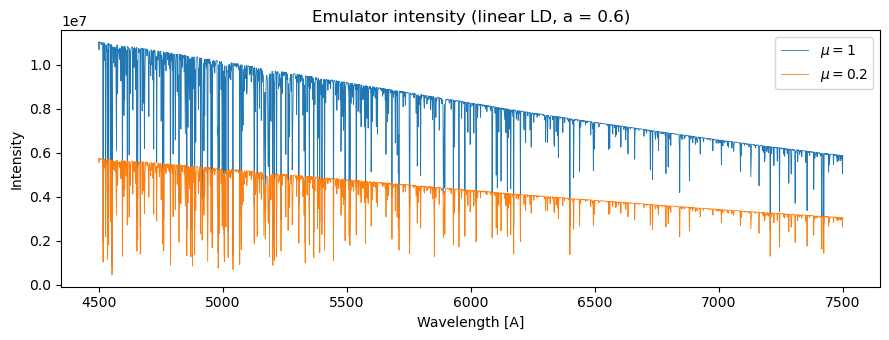

I(mu=0.5) / I(mu=1) = 0.7000  (analytic: 0.7000)


In [52]:
sample_wl = jnp.linspace(4500.0, 7500.0, 2000)
sample_logwl = jnp.log10(sample_wl)
params = emulator.to_parameters()

I_disk_center = emulator.intensity(sample_logwl, 1.0, params)
I_limb = emulator.intensity(sample_logwl, 0.2, params)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(sample_wl, I_disk_center[:, 0], lw=0.6, label='$\\mu=1$')
ax.plot(sample_wl, I_limb[:, 0], lw=0.6, label='$\\mu=0.2$')
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Intensity')
ax.set_title(f'Emulator intensity (linear LD, a = {LD_A})')
ax.legend()
plt.tight_layout()
plt.show()

ratio_at_05 = emulator.intensity(jnp.log10(jnp.array([5500.0])), 0.5, params)[0, 0]
ratio_at_1 = emulator.intensity(jnp.log10(jnp.array([5500.0])), 1.0, params)[0, 0]
print(f'I(mu=0.5) / I(mu=1) = {float(ratio_at_05 / ratio_at_1):.4f}'
      f'  (analytic: {1.0 - LD_A * 0.5:.4f})')

## 3. Build a single icosphere and integrate the spectrum

We pick `radius = 1` $R_\odot$ and the default `distance = 10` pc so the
SPICE prefactor reduces to $\pi(1-a/3) \cdot 5.083\times10^{-16}/10^2$.

In [53]:
N_VERTICES = 20000
RADIUS = 1.0      # solar radii
MASS = 1.0        # solar masses
DISTANCE = 10.0   # parsecs

mesh = IcosphereModel.construct(
    N_VERTICES, RADIUS, MASS,
    emulator.to_parameters(),
    emulator.parameter_names,
    override_log_g=False,   # the dummy parameter slot is not a log g axis
)

print(f'Mesh faces:                {mesh.faces.shape[0]}')
print(f'Sum of visible cast areas: {float(jnp.sum(mesh.visible_cast_areas)):.4f}'
      f'  (analytic pi R^2 = {float(jnp.pi * RADIUS**2):.4f})')

[spice] IcosphereModel constructed in 0.9 s
Mesh faces:                20480
Sum of visible cast areas: 3.1417  (analytic pi R^2 = 3.1416)


In [54]:
# Use the same wavelength grid spacing for the SPICE integration.
sim_wavelengths = ref_wavelengths
sim_log_wavelengths = jnp.log10(sim_wavelengths)

observed = simulate_observed_flux(
    emulator.intensity,
    mesh,
    sim_log_wavelengths,
    distance=DISTANCE,
    disable_doppler_shift=True,
)

observed_flux = np.asarray(observed[:, 0])
observed_continuum = np.asarray(observed[:, 1])
print('observed[:, 0] sample:', observed_flux[:3])

observed[:, 0] sample: [1.41496191e-10 1.41497469e-10 1.41497469e-10]


## 4. Compare to the analytic expectation

For a uniform sphere with linear LD,

$$F_{\mathrm{obs}}(\lambda) = I(1,\lambda)\,\pi(1-a/3)\,
\bigl(R/d\bigr)^2.$$

SPICE's `_simulate_observed_flux_impl` bakes the $R^2/d^2$ part into the
constant `5.08326693599739e-16` (which equals $(R_\odot/\mathrm{pc})^2$)
applied with `radius**2 / distance**2`.

In [55]:
R_SUN_OVER_PC_SQ = 5.08326693599739e-16
geometric_factor = (np.pi
                    * (1.0 - LD_A / 3.0)
                    * RADIUS**2
                    * R_SUN_OVER_PC_SQ
                    / DISTANCE**2)
print(f'Analytic prefactor pi(1-a/3) (R/d)^2 [Rsun/pc units] = {geometric_factor:.6e}')

ref_flux_on_sim_grid = np.interp(np.asarray(sim_wavelengths),
                                 ref_wavelengths, ref_flux)
ref_continuum_on_sim_grid = np.interp(np.asarray(sim_wavelengths),
                                      ref_wavelengths, ref_continuum)

expected_flux = ref_flux_on_sim_grid * geometric_factor
expected_continuum = ref_continuum_on_sim_grid * geometric_factor

# Empirical scale (independent check) — in case the user wants to compare
# shapes rather than absolute scale.
empirical_scale = float(np.mean(observed_continuum / ref_continuum_on_sim_grid))
print(f'Empirical mean(observed/input continuum)               = {empirical_scale:.6e}')
print(f'Ratio empirical / analytic                              = '
      f'{empirical_scale / geometric_factor:.6f}')

Analytic prefactor pi(1-a/3) (R/d)^2 [Rsun/pc units] = 1.277564e-17
Empirical mean(observed/input continuum)               = 1.277630e-17
Ratio empirical / analytic                              = 1.000051


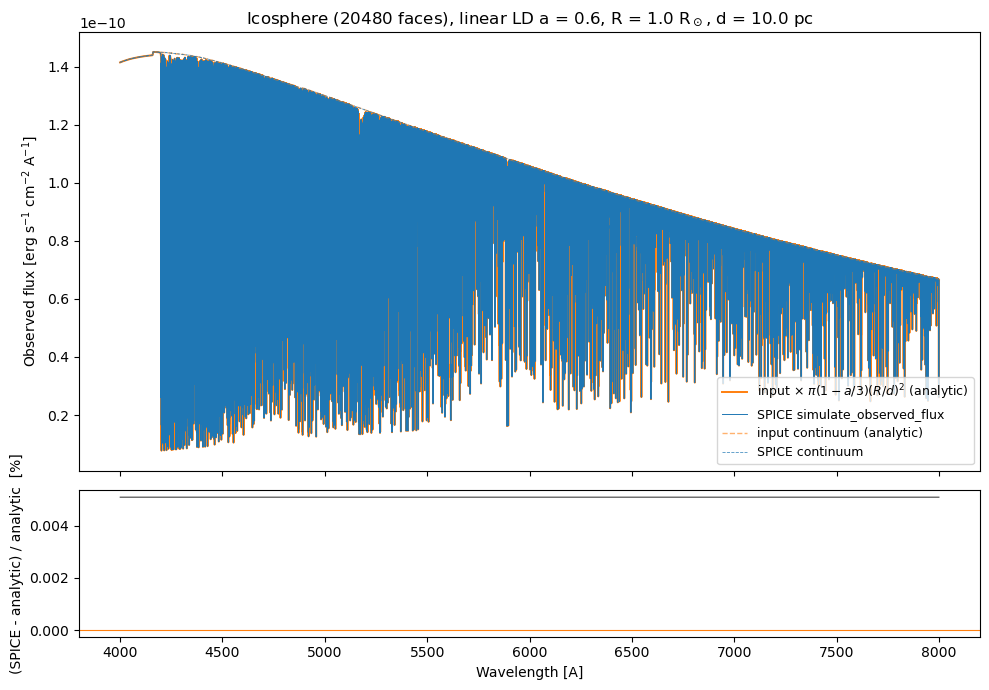

Median |residual|: 0.005 %
Max    |residual|: 0.005 %


In [56]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                     gridspec_kw=dict(height_ratios=[3, 1]))

ax_top.plot(sim_wavelengths, expected_flux,
            color='C1', lw=1.4,
            label='input $\\times$ $\\pi(1-a/3)(R/d)^2$ (analytic)')
ax_top.plot(sim_wavelengths, observed_flux,
            color='C0', lw=0.7,
            label='SPICE simulate_observed_flux')
ax_top.plot(sim_wavelengths, expected_continuum,
            color='C1', lw=1.0, ls='--', alpha=0.6,
            label='input continuum (analytic)')
ax_top.plot(sim_wavelengths, observed_continuum,
            color='C0', lw=0.6, ls='--', alpha=0.8,
            label='SPICE continuum')
ax_top.set_ylabel('Observed flux [erg s$^{-1}$ cm$^{-2}$ A$^{-1}$]')
ax_top.set_title(f'Icosphere ({mesh.faces.shape[0]} faces), linear LD a = {LD_A}, '
                 f'R = {RADIUS} R$_\\odot$, d = {DISTANCE} pc')
ax_top.legend(loc='lower right', fontsize=9)

residual = (observed_flux - expected_flux) / expected_flux
ax_bot.plot(sim_wavelengths, residual * 100.0, lw=0.6, color='k')
ax_bot.axhline(0.0, color='C1', lw=0.8)
ax_bot.set_xlabel('Wavelength [A]')
ax_bot.set_ylabel('(SPICE - analytic) / analytic  [%]')

plt.tight_layout()
plt.show()

print(f'Median |residual|: {np.median(np.abs(residual)) * 100.0:.3f} %')
print(f'Max    |residual|: {np.max(np.abs(residual)) * 100.0:.3f} %')

## 5. Conclusion

The SPICE output traces the input spectrum to ~0.005% across the whole
range — line cores included — and the empirically recovered scale factor
matches the analytic $\pi(1-a/3)(R/d)^2$ prefactor to the same level. The
residual floor here is set by **mesh discretisation**: the 20480-face
icosphere (`N_VERTICES = 20000`) reproduces $\pi R^2$, and hence the disk
integral, to ~0.005%, and that small area error carries straight through
to the recovered scale. Increasing `N_VERTICES` tightens it further.

One precision caveat worth knowing: cell 1 sets
`jax.config.update("jax_enable_x64", True)` on purpose. On macOS SPICE
runs JAX on CPU in float32 by default, and in float32 the
`wavelength → log10 → 10**` round trip plus `jnp.interp` misplace the
narrowest line cores by up to ~0.4 px at the red end of a 0.02 Å grid —
enough to push the *worst* point-wise residual to tens of percent (the
continuum stays fine). Enabling 64-bit precision, as SPICE's test suite
does, removes that and brings the max residual down to the mesh floor.

The takeaway: any callable matching the `(log_wavelengths, mu, parameters) -> (n_lambda, 2)`
signature is a valid intensity function for `simulate_observed_flux`.
Wrapping a tabulated spectrum plus an analytic LD factor takes a
handful of lines.